## Spike theta phase precession

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
import os
import cupy as cp
import numpy as np
import datajoint as dj
import spyglass as nd
import pandas as pd
import matplotlib.pyplot as plt
import json
import multiprocessing

# ignore datajoint+jupyter async warnings
import warnings
warnings.simplefilter('ignore', category=DeprecationWarning)
warnings.simplefilter('ignore', category=ResourceWarning)

from spyglass.common import (Session, IntervalList,LabMember, LabTeam, Raw, Session, Nwbfile,
                            Electrode,LFPBand,interval_list_intersect)
from spyglass.common import TaskEpoch
import spyglass.spikesorting.v0 as ss

from spyglass.spikesorting.v0 import (SortGroup, 
                                    SortInterval,
                                    SpikeSortingPreprocessingParameters,
                                    SpikeSortingRecording, 
                                    SpikeSorterParameters,
                                    SpikeSortingRecordingSelection,
                                    ArtifactDetectionParameters, ArtifactDetectionSelection,
                                    ArtifactRemovedIntervalList, ArtifactDetection,
                                      SpikeSortingSelection, SpikeSorting,
                                   CuratedSpikeSortingSelection,CuratedSpikeSorting,Curation)
from spyglass.spikesorting.v0.curation_figurl import CurationFigurl,CurationFigurlSelection
from spyglass.spikesorting.v0.spikesorting_curation import MetricParameters,MetricSelection,QualityMetrics
from spyglass.spikesorting.v0.spikesorting_curation import WaveformParameters,WaveformSelection,Waveforms
from spyglass.common.common_position import IntervalPositionInfo, IntervalPositionInfoSelection,IntervalLinearizedPosition

from spyglass.utils.nwb_helper_fn import get_nwb_copy_filename
from pprint import pprint
from spyglass.shijiegu.ripple_detection import removeDataBeforeTrial1
from spyglass.shijiegu.helpers import interpolate_to_new_time
from spyglass.shijiegu.placefield import place_field,placefield_to_peak1dloc
from spyglass.shijiegu.Analysis_SGU import DecodeResultsLinear, SingleUnit
warnings.simplefilter("ignore", category=DeprecationWarning)
warnings.simplefilter("ignore", category=ResourceWarning)
warnings.filterwarnings('ignore')

[2025-11-24 15:51:24,668][INFO]: DataJoint 0.14.4 connected to shijiegu-alt@lmf-db.cin.ucsf.edu:3306


In [283]:
import matplotlib
from spyglass.shijiegu.helpers import interval_union
from spyglass.shijiegu.Analysis_SGU import TrialChoice,RippleTimes,TetrodeNumber,EpochPos,ExtendedRippleTimes,RippleTimesWithDecode
from spyglass.shijiegu.load import load_run_sessions
from spyglass.shijiegu.singleUnit import (do_mountainSort,electrode_unit,RippleTime2FiringRate,findWaveForms,RippleTime2Index,find_spikes
                            )
from spyglass.shijiegu.singleUnit_classification import (get_spike_info,return_AC_mean,return_spike_width, classify, result_to_dict, result_to_dataframe)

from spyglass.shijiegu.fragmented import permute_frag_cont,find_spike_count_ratio,get_nwb_units,classify_cells,find_firing_cross_correlation
from spyglass.shijiegu.placefield import cell_by_arm

In [255]:
nwb_copy_file_name = "julio20230806_.nwb"
run_session_ids, run_session_names, pos_session_names = load_run_sessions(nwb_copy_file_name)

*nwb_file_name *epoch    epoch_name     position_inter
+------------+ +-------+ +------------+ +------------+
julio20230806_ 1         01_Seq2Sleep1  pos 0 valid ti
julio20230806_ 2         02_Seq2Session pos 1 valid ti
julio20230806_ 3         03_Seq2Sleep2  pos 2 valid ti
julio20230806_ 4         04_Seq2Session pos 3 valid ti
julio20230806_ 5         05_Seq2Sleep3  pos 4 valid ti
julio20230806_ 6         06_Seq2Session pos 5 valid ti
julio20230806_ 7         07_Seq2Sleep4  pos 6 valid ti
julio20230806_ 8         08_Seq2Session pos 7 valid ti
julio20230806_ 9         09_Seq2Sleep5  pos 8 valid ti
julio20230806_ 10        10_Seq2Session pos 9 valid ti
julio20230806_ 11        11_Seq2Sleep6  pos 10 valid t
 (Total: 11)



In [256]:
epoch_num = 0
session_name = run_session_names[epoch_num]
pos_name = pos_session_names[epoch_num]

### 1. Classify cells in this session

In [259]:
key = {"nwb_file_name": nwb_copy_file_name,
       "sorter":"mountainsort4",
       "sort_interval_name":session_name,
       "curation_id":1}

sort_group_ids = np.unique((QualityMetrics & key).fetch("sort_group_id"))
sort_group_ids_with_good_cell = []
nwb_units_all = {}
for sort_group_id in sort_group_ids:
    nwb_units = electrode_unit(nwb_copy_file_name,session_name,sort_group_id,curation_id = 1)
    if nwb_units is None or len(nwb_units)==0:
        continue
    sort_group_ids_with_good_cell.append(sort_group_id)
    nwb_units_all[sort_group_id] = nwb_units
print("sort groups are: ",sort_group_ids_with_good_cell)

[2025-11-24 15:06:34,433][WARNING]: Skipped checksum for file with hash: d1aee99e-e7ff-cdc7-2ea5-f40023b929d5, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_A3HJC3N99P.nwb
[2025-11-24 15:06:34,454][WARNING]: Skipped checksum for file with hash: d1aee99e-e7ff-cdc7-2ea5-f40023b929d5, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_A3HJC3N99P.nwb
[2025-11-24 15:06:34,462][WARNING]: Skipped checksum for file with hash: d1aee99e-e7ff-cdc7-2ea5-f40023b929d5, and path: /stelmo/nwb/analysis/Julio20230806/Julio20230806_A3HJC3N99P.nwb
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:535: UserWarning: Ignoring cached namespace 'ndx-franklab-novela' version 0.1.0 because version 0.2.0 is already loaded.
  warn("Ignoring cached namespace '%s' version %s because version %s is already loaded."
[2025-11-24 15:06:44,106][WARNING]: Skipped checksum for file with hash: 3f3642ba-9b5b-2cff-9c76-ca31d85c9d5f, and path: /stelmo/nwb/analysis/Ju

sort groups are:  [2, 3, 6, 7, 8, 12, 15, 20, 22, 26, 27, 28, 29, 30, 31, 36, 43, 45, 49, 51, 55, 56, 61]


In [260]:
firing_rate, ac_mean, width = get_spike_info(nwb_units_all, nwb_copy_file_name, session_name)

working on electrode 2
working on electrode 2 unit 2
working on electrode 2 unit 4
working on electrode 2 unit 5
working on electrode 2 unit 6
working on electrode 2 unit 7
working on electrode 2 unit 10
working on electrode 2 unit 12
working on electrode 3
working on electrode 3 unit 2
working on electrode 3 unit 3
working on electrode 3 unit 4
working on electrode 3 unit 5
working on electrode 3 unit 6
working on electrode 3 unit 8
working on electrode 3 unit 9
working on electrode 3 unit 10
working on electrode 3 unit 11
working on electrode 3 unit 13
working on electrode 3 unit 14
working on electrode 3 unit 15
working on electrode 3 unit 16
working on electrode 6
working on electrode 6 unit 2
working on electrode 6 unit 3
working on electrode 6 unit 4
working on electrode 6 unit 5
working on electrode 6 unit 6
working on electrode 6 unit 7
working on electrode 6 unit 11
working on electrode 6 unit 12
working on electrode 6 unit 13
working on electrode 6 unit 14
working on electrod

In [275]:
# Pyramidal cells
#  criterion from Skaggs 1996: 
#  1. have a spike width (peak to valley) of at least 300 us; and 4)
#  2. have an overall mean rate below 5 Hz during the recording session. 
#

# Interneuron a unit was required to
#  1. have a spike width less than 300 us;
#  2. fire with a mean rate above 5 Hz during the recording session.

classification = classify(firing_rate, ac_mean, width)

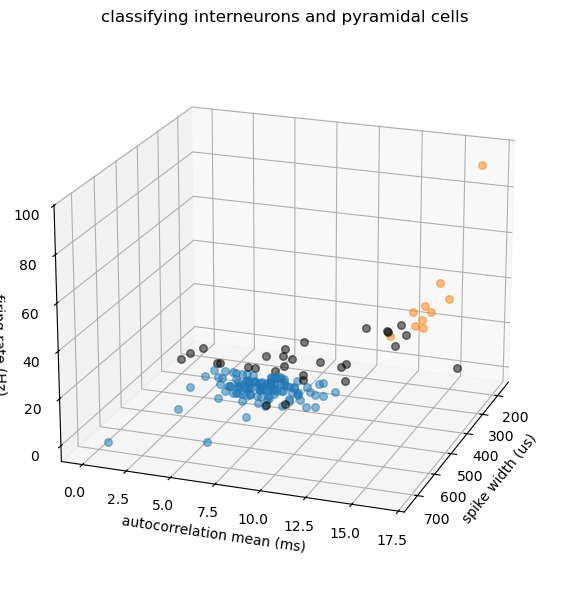

In [276]:
import matplotlib.pyplot as plt
import numpy as np


# Create a figure and a 3D axes
fig = plt.figure(figsize = (6,6))
ax = fig.add_subplot(projection='3d')

# Plot the 3D scatter points
for (e,u) in firing_rate.keys():
    fr = firing_rate[(e,u)]
    ac = ac_mean[(e,u)]
    w = np.abs(width[(e,u)])
    c = classification[(e,u)]
    if c == "pyramidal":
        color = 'C0'
    elif c == "interneuron":
        color = 'C1'
    else:
        color = 'k'
    ax.scatter(w * 1000, ac, fr, s=30, color = color, alpha = 0.5)

# Set labels
ax.set_zlabel("firing rate (Hz)")
ax.set_ylabel("autocorrelation mean (ms)")
ax.set_xlabel('spike width (us)')

# Display the plot
ax.view_init(elev=20, azim=20) 
plt.title('classifying interneurons and pyramidal cells')
plt.tight_layout()
#plt.subplots_adjust(right=0.3) 
#plt.subplots_adjust(bottom=0.1)
plt.show()

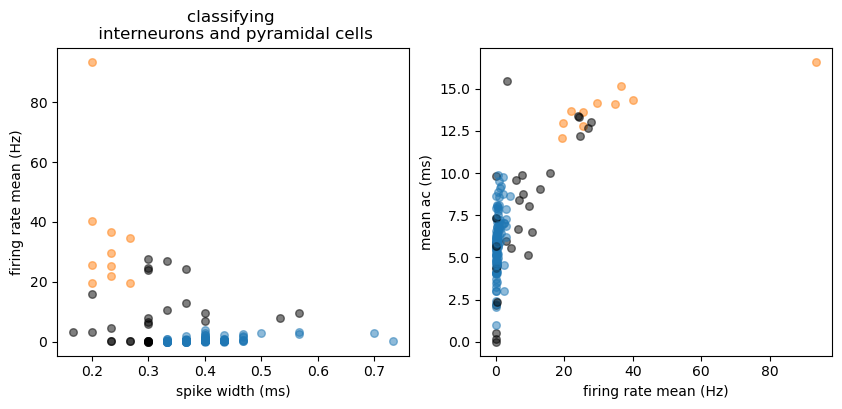

In [277]:
# Create a figure and a 3D axes
fig, axes = plt.subplots(1,2,figsize = (10,4))

# Plot the 3D scatter points
for (e,u) in firing_rate.keys():
    fr = firing_rate[(e,u)]
    w = np.abs(width[(e,u)])
    ac = ac_mean[(e,u)]
    c = classification[(e,u)]
    if c == "pyramidal":
        color = 'C0'
    elif c == "interneuron":
        color = 'C1'
    else:
        color = 'k'
        
    axes[0].scatter(w, fr, s=30, color = color, alpha = 0.5)

    axes[1].scatter(fr, ac, s=30, color = color, alpha = 0.5)

# Set labels
axes[0].set_xlabel('spike width (ms)')
axes[0].set_ylabel("firing rate mean (Hz)")

axes[1].set_xlabel("firing rate mean (Hz)")
axes[1].set_ylabel('mean ac (ms)')

# Display the plot
axes[0].set_title('classifying \n interneurons and pyramidal cells')

#plt.subplots_adjust(right=0.3) 
#plt.subplots_adjust(bottom=0.1)
plt.show()

### insert into spyglass

In [278]:
classification = classify(firing_rate, ac_mean, width)

In [279]:
result = result_to_dict(firing_rate, ac_mean, width, classification)

In [301]:
df = result_to_dataframe(result)

In [302]:
df

firing_rate    ac_mean  spike_width classification
sort_group_id unit_id                                                    
2             2           9.712949   8.037907     0.566667   unclassified
              4           0.185921   2.186047     0.300000   unclassified
              5           6.897749   8.407063     0.400000   unclassified
              6           0.309733   5.173507     0.433333      pyramidal
              7           2.434022   2.981633     0.566667      pyramidal
...                            ...        ...          ...            ...
61            5          93.503224  16.606842     0.200000    interneuron
              6           0.249654   2.332884     0.300000   unclassified
              7           0.545991   7.540864     0.366667      pyramidal
              8           0.470486   5.884769     0.400000      pyramidal
              9           0.626367   9.901308     0.366667      pyramidal

[149 rows x 4 columns]

In [303]:
test_dict = df.to_dict()

In [304]:
test = pd.DataFrame.from_dict(test_dict)

In [305]:
test

firing_rate    ac_mean  spike_width classification
2  2     9.712949   8.037907     0.566667   unclassified
   4     0.185921   2.186047     0.300000   unclassified
   5     6.897749   8.407063     0.400000   unclassified
   6     0.309733   5.173507     0.433333      pyramidal
   7     2.434022   2.981633     0.566667      pyramidal
...           ...        ...          ...            ...
61 5    93.503224  16.606842     0.200000    interneuron
   6     0.249654   2.332884     0.300000   unclassified
   7     0.545991   7.540864     0.366667      pyramidal
   8     0.470486   5.884769     0.400000      pyramidal
   9     0.626367   9.901308     0.366667      pyramidal

[149 rows x 4 columns]

In [281]:
pd.DataFrame(result)

2                                          \
                          2             4             5          6    
firing_rate         9.712949      0.185921      6.897749   0.309733   
ac_mean             8.037907      2.186047      8.407063   5.173507   
spike_width         0.566667           0.3           0.4   0.433333   
classification  unclassified  unclassified  unclassified  pyramidal   

                                                           3              \
                       7          10            12         2          3    
firing_rate      2.434022    0.27401      7.884591   0.168466   0.097832   
ac_mean          2.981633   4.073648      8.773313   5.151203   4.057971   
spike_width      0.566667   0.366667      0.533333        0.4   0.333333   
classification  pyramidal  pyramidal  unclassified  pyramidal  pyramidal   

                           ...         56                          \
                       4   ...         6          7            8    
firing_rate      0.592268  ...   0.704714   0.638951    19.561889   
ac_mean          7.766002  ...     6.9108   5.204977    12.955917   
spike_width           0.4  ...   0.366667   0.366667          0.2   
classification  pyramidal  ...  pyramidal  pyramidal  interneuron   

                         61                                           \
                         2             3            5             6    
firing_rate       40.204393      0.199317    93.503224      0.249654   
ac_mean           14.361398      5.682128    16.606842      2.332884   
spike_width             0.2           0.3          0.2           0.3   
classification  interneuron  unclassified  interneuron  unclassified   

                                                 
                       7          8          9   
firing_rate      0.545991   0.470486   0.626367  
ac_mean          7.540864   5.884769   9.901308  
spike_width      0.366667        0.4   0.366667  
classification  pyramidal  pyramidal  pyramidal  

[4 rows x 149 columns]